In [2]:
# ============================================================
# RMT-DEPENDENT 2D CELLULAR AUTOMATA
# FEATURE EXTRACTION STAGE
# ============================================================
#
# 256 RULES
# Condition:
#       N = S
#       W = E
#
# 8 valid RMTs -> controlled by 8-bit logical rule
# Other 24 RMTs -> fixed to 0
#
# Universe      : 3000 x 3000
# Crop          : central 300 x 300
# Time steps    : 100  (0 to 99)
# Snapshot      : every step
#
# 19 snapshot features
# + Transient Length
# + Cycle Length
# = 21 features / step
#
# 100 steps x 21 features
# = 2100 features / rule
#
# FINAL X_RULES:
#       (256, 2100)
#
# Rule / Rule Binary are identity information only.
# They are NOT included in X_rules.
#
# NO SCALING HERE.
# SCALING WILL BE THE NEXT STEP.
# ============================================================


import numpy as np
import pandas as pd
from tqdm import tqdm
from scipy.ndimage import label
import zlib
import os
import gc


# ============================================================
# 1. PARAMETERS
# ============================================================

n_universe = 3000
n_crop = 300

time_steps = 100
num_rules = 256

output_folder = "RMT_Dependent_256"

os.makedirs(
    output_folder,
    exist_ok=True
)


# ============================================================
# 2. RANDOM INITIAL GRID
#
# Same initial condition for all 256 rules
# ============================================================

rng = np.random.default_rng(42)

initial_grid = rng.integers(
    0,
    2,
    size=(n_universe, n_universe),
    dtype=np.uint8
)


# ============================================================
# 3. CENTRAL 300 x 300 CROP
# ============================================================

crop_start = (
    n_universe - n_crop
) // 2

crop_end = (
    crop_start + n_crop
)


# ============================================================
# 4. VALID RMTs
#
# ORDER:
# N W C E S
#
# CONDITIONS:
# N = S
# W = E
# ============================================================

valid_rmts = []

for N in [0, 1]:

    for W in [0, 1]:

        for C in [0, 1]:

            for E in [0, 1]:

                for S in [0, 1]:

                    if N == S and W == E:

                        valid_rmts.append(
                            (N, W, C, E, S)
                        )


print("\nValid RMTs:")

for rmt in valid_rmts:

    print(
        "".join(
            map(str, rmt)
        )
    )

print(
    "\nNumber of valid RMTs:",
    len(valid_rmts)
)


# ============================================================
# 5. GENERATE 256 RMT-DEPENDENT RULES
#
# 8 valid RMTs get the 8-bit logical rule.
# Remaining 24 RMTs remain 0.
# ============================================================

rmt_rules = []

logical_rules = []

for rule_number in range(256):

    # 8-bit logical rule
    logical_rule = format(
        rule_number,
        "08b"
    )

    logical_rules.append(
        logical_rule
    )

    # All 32 RMTs initially = 0
    rule_table = np.zeros(
        32,
        dtype=np.uint8
    )

    # Fill only the 8 valid RMT positions
    for rmt, output in zip(
        valid_rmts,
        logical_rule
    ):

        N, W, C, E, S = rmt

        # RMT index = N W C E S
        index = (
            (N << 4)
            |
            (W << 3)
            |
            (C << 2)
            |
            (E << 1)
            |
            S
        )

        rule_table[index] = int(
            output
        )

    rmt_rules.append(
        rule_table
    )


rmt_rules = np.array(
    rmt_rules,
    dtype=np.uint8
)


print(
    "\nTotal rules generated:",
    len(rmt_rules)
)


# ============================================================
# 6. SAVE RULE IDENTITY TABLE
#
# This is separate from X_rules.
# ============================================================

rule_identity = pd.DataFrame({

    "Rule":
        np.arange(
            256
        ),

    "Rule Binary":
        logical_rules,

    "32-bit Rule":
        [
            "".join(
                r.astype(str)
            )
            for r in rmt_rules
        ]

})


rule_identity.to_csv(
    os.path.join(
        output_folder,
        "RMT_256_Rule_Identity.csv"
    ),
    index=False
)


# ============================================================
# 7. CA EVOLUTION
#
# PERIODIC BOUNDARY
#
# RMT ORDER:
# N W C E S
# ============================================================

def evolve_vectorized(
    grid,
    rule
):

    N = np.roll(
        grid,
        1,
        axis=0
    )

    S = np.roll(
        grid,
        -1,
        axis=0
    )

    W = np.roll(
        grid,
        1,
        axis=1
    )

    E = np.roll(
        grid,
        -1,
        axis=1
    )

    C = grid

    index = (
        (N << 4)
        |
        (W << 3)
        |
        (C << 2)
        |
        (E << 1)
        |
        S
    )

    return rule[index]


# ============================================================
# 8. BINARY ENTROPY
# ============================================================

def binary_entropy(p):

    if p <= 0 or p >= 1:

        return 0.0

    return -(
        p * np.log2(p)
        +
        (1 - p)
        * np.log2(1 - p)
    )


# ============================================================
# 9. CORRELATION
# ============================================================

def safe_correlation(
    current,
    previous
):

    if previous is None:

        return 0.0

    current = (
        current.ravel()
        .astype(np.float64)
    )

    previous = (
        previous.ravel()
        .astype(np.float64)
    )

    std_current = current.std()
    std_previous = previous.std()

    if (
        std_current == 0
        or
        std_previous == 0
    ):

        if np.array_equal(
            current,
            previous
        ):

            return 1.0

        return 0.0

    correlation = np.corrcoef(
        current,
        previous
    )[0, 1]

    if np.isnan(correlation):

        return 0.0

    return float(correlation)


# ============================================================
# 10. SIMILARITY
# ============================================================

def calculate_similarity(
    current,
    previous
):

    if previous is None:

        return 0.0

    return float(
        np.mean(
            current == previous
        )
    )


# ============================================================
# 11. RUN LENGTHS
# ============================================================

def calculate_run_lengths(
    matrix
):

    rows, cols = matrix.shape

    horizontal_changes = np.count_nonzero(
        matrix[:, 1:]
        !=
        matrix[:, :-1]
    )

    horizontal_runs = (
        rows
        +
        horizontal_changes
    )

    mean_horizontal_run = (
        matrix.size
        /
        horizontal_runs
    )


    vertical_changes = np.count_nonzero(
        matrix[1:, :]
        !=
        matrix[:-1, :]
    )

    vertical_runs = (
        cols
        +
        vertical_changes
    )

    mean_vertical_run = (
        matrix.size
        /
        vertical_runs
    )


    return (
        float(mean_horizontal_run),
        float(mean_vertical_run)
    )


# ============================================================
# 12. 19 SNAPSHOT FEATURES
# ============================================================

def extract_snapshot_features(
    matrix,
    previous,
    previous2
):

    matrix = matrix.astype(
        np.int8,
        copy=False
    )

    rows, cols = matrix.shape


    # --------------------------------------------------------
    # 1. Average Density
    # --------------------------------------------------------

    average_density = float(
        matrix.mean()
    )


    # --------------------------------------------------------
    # 2. Density Variation
    # --------------------------------------------------------

    row_density = matrix.mean(
        axis=1
    )

    density_variation = float(
        row_density.std()
    )


    # --------------------------------------------------------
    # 3. Global Entropy
    # --------------------------------------------------------

    global_entropy = binary_entropy(
        average_density
    )


    # --------------------------------------------------------
    # 4. Mean Row Entropy
    # --------------------------------------------------------

    row_entropy = np.zeros(
        rows,
        dtype=np.float64
    )

    valid = (
        (row_density > 0)
        &
        (row_density < 1)
    )

    p = row_density[valid]

    row_entropy[valid] = -(
        p * np.log2(p)
        +
        (1 - p)
        * np.log2(1 - p)
    )

    mean_row_entropy = float(
        row_entropy.mean()
    )


    # --------------------------------------------------------
    # 5. Row Entropy Variation
    # --------------------------------------------------------

    row_entropy_variation = float(
        row_entropy.std()
    )


    # --------------------------------------------------------
    # 6. Unique States
    # --------------------------------------------------------

    unique_states = int(
        np.unique(
            matrix,
            axis=0
        ).shape[0]
    )


    # --------------------------------------------------------
    # 7. Unique State Ratio
    # --------------------------------------------------------

    unique_state_ratio = float(
        unique_states / rows
    )


    # --------------------------------------------------------
    # 8. Horizontal Transitions
    # --------------------------------------------------------

    horizontal_transitions = float(
        np.mean(
            matrix[:, 1:]
            !=
            matrix[:, :-1]
        )
    )


    # --------------------------------------------------------
    # 9. Vertical Transitions
    # --------------------------------------------------------

    vertical_transitions = float(
        np.mean(
            matrix[1:, :]
            !=
            matrix[:-1, :]
        )
    )


    # --------------------------------------------------------
    # 10. Lag-1 Correlation
    # --------------------------------------------------------

    lag1_correlation = safe_correlation(
        matrix,
        previous
    )


    # --------------------------------------------------------
    # 11. Lag-2 Correlation
    # --------------------------------------------------------

    lag2_correlation = safe_correlation(
        matrix,
        previous2
    )


    # --------------------------------------------------------
    # 12. Lag-1 Similarity
    # --------------------------------------------------------

    lag1_similarity = calculate_similarity(
        matrix,
        previous
    )


    # --------------------------------------------------------
    # 13. Lag-2 Similarity
    # --------------------------------------------------------

    lag2_similarity = calculate_similarity(
        matrix,
        previous2
    )


    # --------------------------------------------------------
    # 14 & 15. Run Lengths
    # --------------------------------------------------------

    (
        mean_horizontal_run,
        mean_vertical_run
    ) = calculate_run_lengths(
        matrix
    )


    # --------------------------------------------------------
    # 16. Connected Components
    # --------------------------------------------------------

    structure = np.ones(
        (3, 3),
        dtype=np.int8
    )

    labelled, components = label(
        matrix,
        structure=structure
    )


    # --------------------------------------------------------
    # 17. Largest Component Ratio
    # --------------------------------------------------------

    if components > 0:

        component_sizes = np.bincount(
            labelled.ravel()
        )[1:]

        largest_component_ratio = float(
            component_sizes.max()
            /
            matrix.size
        )

    else:

        largest_component_ratio = 0.0


    # --------------------------------------------------------
    # 18. Compression Ratio
    # --------------------------------------------------------

    compressed = zlib.compress(
        matrix.tobytes(),
        level=1
    )

    compression_ratio = float(
        len(compressed)
        /
        matrix.nbytes
    )


    # --------------------------------------------------------
    # 19. Mean Absolute Row-Density Change
    # --------------------------------------------------------

    mean_row_density_change = float(
        np.mean(
            np.abs(
                np.diff(row_density)
            )
        )
    )


    return [

        average_density,

        density_variation,

        global_entropy,

        mean_row_entropy,

        row_entropy_variation,

        unique_states,

        unique_state_ratio,

        horizontal_transitions,

        vertical_transitions,

        lag1_correlation,

        lag2_correlation,

        lag1_similarity,

        lag2_similarity,

        mean_horizontal_run,

        mean_vertical_run,

        components,

        largest_component_ratio,

        compression_ratio,

        mean_row_density_change

    ]


# ============================================================
# 13. FEATURE NAMES
# ============================================================

feature_names = [

    "Average Density",

    "Density Variation",

    "Global Entropy",

    "Mean Row Entropy",

    "Row Entropy Variation",

    "Unique States",

    "Unique State Ratio",

    "Horizontal Transitions",

    "Vertical Transitions",

    "Lag-1 Correlation",

    "Lag-2 Correlation",

    "Lag-1 Similarity",

    "Lag-2 Similarity",

    "Mean Horizontal Run Length",

    "Mean Vertical Run Length",

    "Connected Components",

    "Largest Component Ratio",

    "Compression Ratio",

    "Mean Absolute Row-Density Change",

    "Transient Length",

    "Cycle Length"

]


# ============================================================
# 14. PRE-ALLOCATE FINAL FEATURE MATRIX
#
# 100 steps × 21 features
# = 2100 features
#
# 256 rules × 2100
# ============================================================

X_rules = np.zeros(
    (
        num_rules,
        time_steps * 21
    ),
    dtype=np.float32
)


# ============================================================
# 15. PROCESS EACH RULE
# ============================================================

for rule_id in tqdm(
    range(num_rules),
    desc="Processing 256 rules"
):

    rule = rmt_rules[
        rule_id
    ]


    # --------------------------------------------------------
    # Same initial condition
    # --------------------------------------------------------

    grid = initial_grid.copy()


    # --------------------------------------------------------
    # Store 100 crops
    # --------------------------------------------------------

    snapshots = []


    # --------------------------------------------------------
    # Store 19 features for each step
    # --------------------------------------------------------

    temporal_features = []


    # Previous snapshots
    previous = None
    previous2 = None


    # ========================================================
    # EVOLVE FROM STEP 0 TO 99
    # ========================================================

    for step in range(
        time_steps
    ):


        # ----------------------------------------------------
        # Take central 300 × 300 snapshot
        # ----------------------------------------------------

        crop = grid[
            crop_start:crop_end,
            crop_start:crop_end
        ].copy()


        snapshots.append(
            crop
        )


        # ----------------------------------------------------
        # Calculate 19 snapshot features
        # ----------------------------------------------------

        features = extract_snapshot_features(

            crop,

            previous,

            previous2

        )


        temporal_features.append(
            features
        )


        # ----------------------------------------------------
        # Update history
        # ----------------------------------------------------

        previous2 = previous

        previous = crop


        # ----------------------------------------------------
        # Evolve to next step
        # ----------------------------------------------------

        grid = evolve_vectorized(
            grid,
            rule
        )


    # ========================================================
    # 16. CALCULATE TRANSIENT/CYCLE AT EACH STEP
    #
    # For every step t:
    # use states observed from 0...t.
    #
    # Before a repetition is found:
    #       transient = 0
    #       cycle = 0
    #
    # Once detected:
    #       values are carried forward.
    # ========================================================

    state_history = {}

    transient_so_far = 0
    cycle_so_far = 0

    cycle_found = False


    for step in range(
        time_steps
    ):

        current_state = (
            snapshots[step].tobytes()
        )


        if not cycle_found:

            if current_state in state_history:

                first_occurrence = (
                    state_history[
                        current_state
                    ]
                )

                transient_so_far = (
                    first_occurrence
                )

                cycle_so_far = (
                    step
                    -
                    first_occurrence
                )

                cycle_found = True

            else:

                state_history[
                    current_state
                ] = step


        # ----------------------------------------------------
        # Append the two rule-behaviour features
        # to THIS temporal step
        # ----------------------------------------------------

        temporal_features[
            step
        ].append(
            transient_so_far
        )

        temporal_features[
            step
        ].append(
            cycle_so_far
        )


    # ========================================================
    # 17. FLATTEN
    #
    # 100 × 21
    # → 2100
    # ========================================================

    temporal_vector = np.asarray(
        temporal_features,
        dtype=np.float32
    ).reshape(-1)


    # ========================================================
    # SAFETY CHECK
    # ========================================================

    assert (
        temporal_vector.shape[0]
        ==
        2100
    )


    # ========================================================
    # 18. ONE ROW = ONE RULE
    #
    # Rule is NOT inserted into X_rules.
    # ========================================================

    X_rules[
        rule_id
    ] = temporal_vector


    # --------------------------------------------------------
    # Memory cleanup
    # --------------------------------------------------------

    del snapshots
    del temporal_features
    del grid

    gc.collect()


# ============================================================
# 19. FINAL CHECK
# ============================================================

print("\n")
print("=" * 60)

print(
    "FEATURE EXTRACTION COMPLETE"
)

print("=" * 60)

print(
    "Number of rules:",
    num_rules
)

print(
    "Steps per rule:",
    time_steps
)

print(
    "Snapshot features:",
    19
)

print(
    "Transient + Cycle:",
    2
)

print(
    "Features per step:",
    21
)

print(
    "Features per rule:",
    2100
)

print(
    "Final X_rules shape:",
    X_rules.shape
)

print(
    "Expected:",
    "(256, 2100)"
)

print("=" * 60)


# ============================================================
# 20. SAVE RAW FEATURE MATRIX
#
# NO SCALING YET
# ============================================================

np.save(
    os.path.join(
        output_folder,
        "X_rules_raw.npy"
    ),
    X_rules
)


# ============================================================
# 21. CREATE FEATURE-NAME LIST
#
# This tells us exactly which column corresponds
# to which feature and step.
# ============================================================

all_feature_columns = []

for step in range(
    time_steps
):

    for feature in feature_names:

        all_feature_columns.append(
            f"T{step}_{feature}"
        )


assert len(
    all_feature_columns
) == 2100


# ============================================================
# 22. SAVE FEATURE NAMES
# ============================================================

pd.DataFrame({

    "Column_Index":
        np.arange(2100),

    "Feature":
        all_feature_columns

}).to_csv(
    os.path.join(
        output_folder,
        "Feature_Column_Names.csv"
    ),
    index=False
)


# ============================================================
# 23. SAVE RULE IDENTITY
# ============================================================

rule_identity.to_csv(
    os.path.join(
        output_folder,
        "Rule_Identity.csv"
    ),
    index=False
)


# ============================================================
# FINAL
# ============================================================

print(
    "\nRaw feature matrix saved."
)

print(
    "Scaling has NOT been performed."
)

print(
    "Next step: StandardScaler on X_rules."
)


Valid RMTs:
00000
00100
01010
01110
10001
10101
11011
11111

Number of valid RMTs: 8

Total rules generated: 256


Processing 256 rules: 100%|██████████| 256/256 [33:22<00:00,  7.82s/it]



FEATURE EXTRACTION COMPLETE
Number of rules: 256
Steps per rule: 100
Snapshot features: 19
Transient + Cycle: 2
Features per step: 21
Features per rule: 2100
Final X_rules shape: (256, 2100)
Expected: (256, 2100)

Raw feature matrix saved.
Scaling has NOT been performed.
Next step: StandardScaler on X_rules.


K-MEANS CLUSTERING

Raw feature shape: (256, 2100)
Scaled feature shape: (256, 2100)


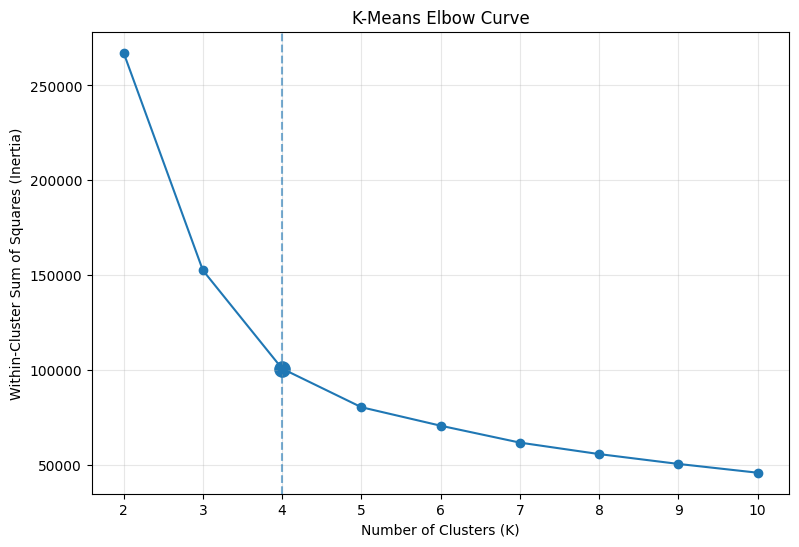


K derived from elbow curve: 4

K-Means cluster counts: 0    70
1    64
2    64
3    58
Name: count, dtype: int64


K-MEANS RESULTS
K: 4
Silhouette Score: 0.5901599
Calinski-Harabasz Index: 359.54938
Davies-Bouldin Index: 0.9177939828609257

K-Means clustering completed.


In [3]:
# ============================================================
# K-MEANS CLUSTERING
# 256 RULES × 2100 FEATURES
# NO PCA
# K IS AUTOMATICALLY DERIVED FROM ELBOW CURVE
# ============================================================

!pip install kneed

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

from sklearn.metrics import (
    silhouette_score,
    calinski_harabasz_score,
    davies_bouldin_score
)

from kneed import KneeLocator


# ============================================================
# 1. LOAD FEATURES
# ============================================================

X_rules = np.load(
    "RMT_Dependent_256/X_rules_raw.npy"
)

rule_identity = pd.read_csv(
    "RMT_Dependent_256/Rule_Identity.csv"
)

print("Raw feature shape:", X_rules.shape)


# ============================================================
# 2. CHECK
# ============================================================

assert X_rules.shape == (256, 2100)
assert len(rule_identity) == 256


# ============================================================
# 3. STANDARDIZATION
# ============================================================

scaler = StandardScaler()

X_scaled = scaler.fit_transform(
    X_rules
)

print(
    "Scaled feature shape:",
    X_scaled.shape
)


# ============================================================
# 4. CALCULATE ELBOW VALUES
# ============================================================

k_values = list(
    range(2, 11)
)

inertias = []

for k in k_values:

    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=20
    )

    model.fit(
        X_scaled
    )

    inertias.append(
        model.inertia_
    )


# ============================================================
# 5. AUTOMATIC ELBOW DETECTION
# ============================================================

knee = KneeLocator(

    k_values,
    inertias,

    curve="convex",

    direction="decreasing"

)

k_derived = knee.knee


# ============================================================
# 6. ELBOW CURVE
# ============================================================

plt.figure(
    figsize=(9, 6)
)

plt.plot(
    k_values,
    inertias,
    marker="o"
)

if k_derived is not None:

    elbow_index = k_values.index(
        k_derived
    )

    plt.scatter(
        k_derived,
        inertias[elbow_index],
        s=120
    )

    plt.axvline(
        k_derived,
        linestyle="--",
        alpha=0.6
    )

plt.xlabel(
    "Number of Clusters (K)"
)

plt.ylabel(
    "Within-Cluster Sum of Squares (Inertia)"
)

plt.title(
    "K-Means Elbow Curve"
)

plt.xticks(
    k_values
)

plt.grid(
    True,
    alpha=0.3
)

plt.show()


# ============================================================
# 7. CHECK DERIVED K
# ============================================================

if k_derived is None:

    raise ValueError(
        "Elbow point could not be detected automatically."
    )

print(
    "\nK derived from elbow curve:",
    k_derived
)


# ============================================================
# 8. FINAL K-MEANS
# ============================================================

kmeans_final = KMeans(

    n_clusters=k_derived,

    random_state=42,

    n_init=20

)

kmeans_labels = kmeans_final.fit_predict(
    X_scaled
)


# ============================================================
# 9. CLUSTER COUNTS
# ============================================================

cluster_counts = (
    pd.Series(
        kmeans_labels
    )
    .value_counts()
    .sort_index()
)

print(
    "\nK-Means cluster counts:",
    cluster_counts
)


# ============================================================
# 10. METRICS
# ============================================================

silhouette = silhouette_score(
    X_scaled,
    kmeans_labels
)

calinski = calinski_harabasz_score(
    X_scaled,
    kmeans_labels
)

davies = davies_bouldin_score(
    X_scaled,
    kmeans_labels
)


print("\n")
print("=" * 60)

print(
    "K-MEANS RESULTS"
)

print("=" * 60)

print(
    "K:",
    k_derived
)

print(
    "Silhouette Score:",
    silhouette
)

print(
    "Calinski-Harabasz Index:",
    calinski
)

print(
    "Davies-Bouldin Index:",
    davies
)

print("=" * 60)


# ============================================================
# 11. ADD CLUSTER LABELS
# ============================================================

results = rule_identity.copy()

results[
    "KMeans_Cluster"
] = kmeans_labels


# ============================================================
# 12. SAVE RESULTS
# ============================================================

results.to_csv(
    "RMT_Dependent_256/KMeans_Results.csv",
    index=False
)

results.to_excel(
    "RMT_Dependent_256/KMeans_Results.xlsx",
    index=False
)


# ============================================================
# 13. SAVE METRICS
# ============================================================

metrics = pd.DataFrame({

    "Metric": [

        "Number of Rules",

        "Features per Rule",

        "K from Elbow Curve",

        "Silhouette Score",

        "Calinski-Harabasz Index",

        "Davies-Bouldin Index"

    ],

    "Value": [

        256,

        2100,

        k_derived,

        silhouette,

        calinski,

        davies

    ]

})

metrics.to_csv(
    "RMT_Dependent_256/KMeans_Metrics.csv",
    index=False
)


print(
    "\nK-Means clustering completed."
)

HIERARCHIAL AGGLOMERATIVE CLUSTERING

Raw feature shape: (256, 2100)
Scaled feature shape: (256, 2100)


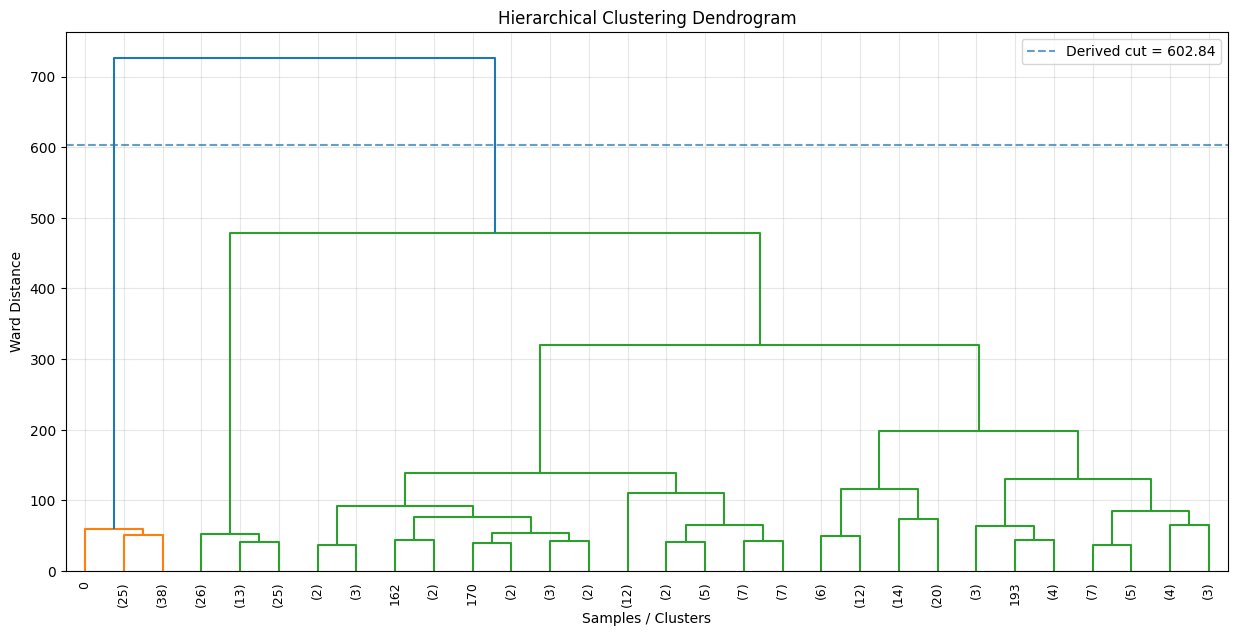



HIERARCHICAL CLUSTER DERIVATION
Largest distance gap: 247.3695451057112
Lower merge distance: 479.15079193599894
Upper merge distance: 726.5203370417101
Derived cut distance: 602.8355644888545
Derived number of clusters: 2

Hierarchical cluster counts:
0     64
1    192
Name: count, dtype: int64


HIERARCHICAL CLUSTERING RESULTS
Derived K: 2
Silhouette Score: 0.51508355
Calinski-Harabasz Index: 250.79915
Davies-Bouldin Index: 0.5827805684242837

Hierarchical clustering completed.


In [5]:
# ============================================================
# HIERARCHICAL CLUSTERING
# 256 RULES × 2100 FEATURES

# K IS AUTOMATICALLY DERIVED FROM DENDROGRAM
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler

from sklearn.cluster import AgglomerativeClustering

from sklearn.metrics import (
    silhouette_score,
    calinski_harabasz_score,
    davies_bouldin_score
)

from scipy.cluster.hierarchy import (
    linkage,
    dendrogram,
    fcluster
)


# ============================================================
# 1. LOAD FEATURES
# ============================================================

X_rules = np.load(
    "RMT_Dependent_256/X_rules_raw.npy"
)

rule_identity = pd.read_csv(
    "RMT_Dependent_256/Rule_Identity.csv"
)

print(
    "Raw feature shape:",
    X_rules.shape
)


# ============================================================
# 2. CHECK
# ============================================================

assert X_rules.shape == (256, 2100)
assert len(rule_identity) == 256


# ============================================================
# 3. STANDARDIZATION
# ============================================================

scaler = StandardScaler()

X_scaled = scaler.fit_transform(
    X_rules
)

print(
    "Scaled feature shape:",
    X_scaled.shape
)


# ============================================================
# 4. LINKAGE
# ============================================================

Z = linkage(
    X_scaled,
    method="ward"
)


# ============================================================
# 5. LINKAGE DISTANCES
#
# Z[:, 2] contains the distance at which
# clusters are merged.
# ============================================================

merge_distances = Z[
    :,
    2
]


# ============================================================
# 6. FIND LARGEST DISTANCE GAP
# ============================================================

distance_gaps = np.diff(
    merge_distances
)

largest_gap_index = np.argmax(
    distance_gaps
)


# ============================================================
# 7. DERIVE CUT DISTANCE
#
# Place the cut between the two merge distances
# surrounding the largest gap.
# ============================================================

lower_distance = merge_distances[
    largest_gap_index
]

upper_distance = merge_distances[
    largest_gap_index + 1
]

cut_distance = (
    lower_distance
    +
    upper_distance
) / 2


# ============================================================
# 8. DERIVE NUMBER OF CLUSTERS
# ============================================================

hierarchical_labels = fcluster(

    Z,

    t=cut_distance,

    criterion="distance"

)

# Convert labels to 0-based labels

hierarchical_labels = (
    hierarchical_labels - 1
)

k_derived = len(
    np.unique(
        hierarchical_labels
    )
)


# ============================================================
# 9. DENDROGRAM
# ============================================================

plt.figure(
    figsize=(15, 7)
)

dendrogram(
    Z,

    truncate_mode="lastp",

    p=30,

    leaf_rotation=90,

    leaf_font_size=9,

    color_threshold=cut_distance
)

plt.axhline(
    cut_distance,
    linestyle="--",
    alpha=0.7,
    label=f"Derived cut = {cut_distance:.2f}"
)

plt.title(
    "Hierarchical Clustering Dendrogram"
)

plt.xlabel(
    "Samples / Clusters"
)

plt.ylabel(
    "Ward Distance"
)

plt.legend()

plt.grid(
    True,
    alpha=0.3
)

plt.show()


# ============================================================
# 10. DISPLAY DERIVED VALUES
# ============================================================

print("\n")
print("=" * 60)

print(
    "HIERARCHICAL CLUSTER DERIVATION"
)

print("=" * 60)

print(
    "Largest distance gap:",
    distance_gaps[largest_gap_index]
)

print(
    "Lower merge distance:",
    lower_distance
)

print(
    "Upper merge distance:",
    upper_distance
)

print(
    "Derived cut distance:",
    cut_distance
)

print(
    "Derived number of clusters:",
    k_derived
)

print("=" * 60)


# ============================================================
# 11. CLUSTER COUNTS
# ============================================================

cluster_counts = (
    pd.Series(
        hierarchical_labels
    )
    .value_counts()
    .sort_index()
)

print(
    "\nHierarchical cluster counts:"
)

print(
    cluster_counts
)


# ============================================================
# 12. CLUSTERING METRICS
# ============================================================

silhouette = silhouette_score(
    X_scaled,
    hierarchical_labels
)

calinski = calinski_harabasz_score(
    X_scaled,
    hierarchical_labels
)

davies = davies_bouldin_score(
    X_scaled,
    hierarchical_labels
)


print("\n")
print("=" * 60)

print(
    "HIERARCHICAL CLUSTERING RESULTS"
)

print("=" * 60)

print(
    "Derived K:",
    k_derived
)

print(
    "Silhouette Score:",
    silhouette
)

print(
    "Calinski-Harabasz Index:",
    calinski
)

print(
    "Davies-Bouldin Index:",
    davies
)

print("=" * 60)


# ============================================================
# 13. ADD CLUSTER LABELS
# ============================================================

results = rule_identity.copy()

results[
    "Hierarchical_Cluster"
] = hierarchical_labels


# ============================================================
# 14. SAVE RESULTS
# ============================================================

results.to_csv(
    "RMT_Dependent_256/Hierarchical_Results.csv",
    index=False
)

results.to_excel(
    "RMT_Dependent_256/Hierarchical_Results.xlsx",
    index=False
)


# ============================================================
# 15. SAVE METRICS
# ============================================================

metrics = pd.DataFrame({

    "Metric": [

        "Number of Rules",

        "Features per Rule",

        "K from Dendrogram",

        "Cut Distance",

        "Silhouette Score",

        "Calinski-Harabasz Index",

        "Davies-Bouldin Index"

    ],

    "Value": [

        256,

        2100,

        k_derived,

        cut_distance,

        silhouette,

        calinski,

        davies

    ]

})

metrics.to_csv(
    "RMT_Dependent_256/Hierarchical_Metrics.csv",
    index=False
)


print(
    "\nHierarchical clustering completed."
)

DBSACN CLUSTERING

Raw feature matrix shape: (256, 2100)
Rule identity shape: (256, 3)


INPUT VALIDATION
RMT Condition:
    N = S
    E = W

Number of rules: 256
Features per rule: 2100
Time steps: 100
Features per time step: 21
Actual matrix shape: (256, 2100)

No NaN or infinite values found.

Scaled feature matrix shape: (256, 2100)


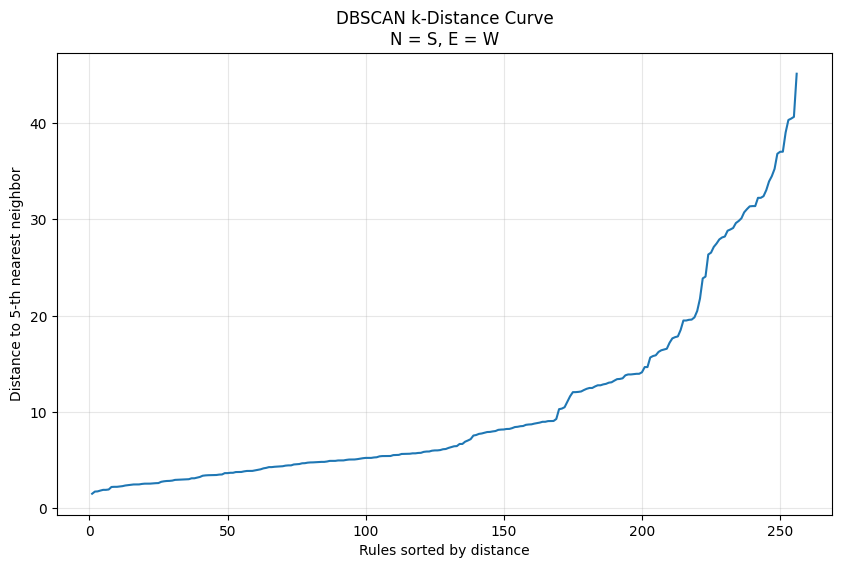



AUTOMATIC DBSCAN PARAMETER SELECTION
RMT Condition:
    N = S
    E = W

min_samples: 5
Automatically selected eps: 32.4173469543457
Knee position: 244


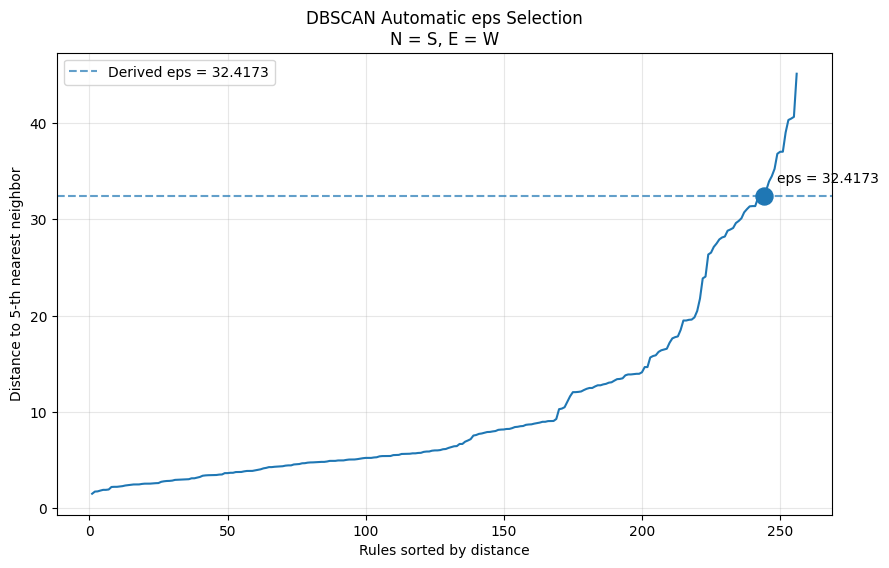



DBSCAN LABELS
Labels: [-1  0  1  2  3  4  5]


DBSCAN CLUSTER SUMMARY
Number of clusters: 6
Number of noise rules: 5
Noise percentage: 1.95%
Number of clustered rules: 251


CLUSTER COUNTS
Noise (-1): 5 rules
Cluster 0: 63 rules
Cluster 1: 64 rules
Cluster 2: 104 rules
Cluster 3: 7 rules
Cluster 4: 8 rules
Cluster 5: 5 rules


DBSCAN CLUSTERING RESULTS
RMT Condition:
    N = S
    E = W

Valid RMTs: 8
Number of rules: 256
Features per rule: 2100
Features per time step: 21
Time steps: 100

min_samples: 5
Derived eps: 32.4173469543457
Number of clusters: 6
Noise rules: 5
Noise percentage: 1.95%

Silhouette Score: 0.5348727
Calinski-Harabasz Index: 185.15196
Davies-Bouldin Index: 0.9449971423511881


RULE → DBSCAN CLUSTER
 Rule  Rule Binary                      32-bit Rule  DBSCAN_Cluster
    0            0 00000000000000000000000000000000              -1
    1            1 00000000000000000000000000000001               0
    2           10 00000000000000000000000000010000              

In [6]:
# ============================================================
# DBSCAN CLUSTERING
# RMT-DEPENDENT 2D CELLULAR AUTOMATA
#
# YOUR CASE:
#
#       N = S
#       E = W
#
# 256 RULES
# 2100 FEATURES / RULE
#
# PIPELINE:
#
#       X_rules
#           ↓
#     StandardScaler
#           ↓
#     k-distance curve
#           ↓
#   Automatically determine eps
#           ↓
#         DBSCAN
#           ↓
#   Behavioral Clusters
#
# PARAMETERS:
#
#       eps          → automatically selected
#       min_samples  → fixed at 5
#
# METRICS:
#
#       Silhouette Score
#       Calinski-Harabasz Index
#       Davies-Bouldin Index
#
# NO PCA
# RULE IDENTITY IS NOT USED AS A FEATURE
# ============================================================


# ============================================================
# 1. IMPORT LIBRARIES
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os

from sklearn.preprocessing import StandardScaler

from sklearn.cluster import DBSCAN

from sklearn.neighbors import NearestNeighbors

from sklearn.metrics import (
    silhouette_score,
    calinski_harabasz_score,
    davies_bouldin_score
)

from kneed import KneeLocator


# ============================================================
# 2. PARAMETERS
# ============================================================

# Folder containing your N=S ; E=W data
output_folder = "RMT_Dependent_256"

num_rules = 256

time_steps = 100

features_per_step = 21

total_features = (
    time_steps *
    features_per_step
)


# ============================================================
# 3. DBSCAN PARAMETERS
# ============================================================

# Fixed value
min_samples = 5


# ============================================================
# 4. LOAD RAW FEATURE MATRIX
#
# Expected shape:
#
#       (256, 2100)
# ============================================================

X_rules = np.load(
    os.path.join(
        output_folder,
        "X_rules_raw.npy"
    )
)


print(
    "Raw feature matrix shape:",
    X_rules.shape
)


# ============================================================
# 5. LOAD RULE IDENTITY
#
# Rule identity is NOT used for clustering.
# It is attached only after clustering.
# ============================================================

rule_identity = pd.read_csv(
    os.path.join(
        output_folder,
        "Rule_Identity.csv"
    )
)


print(
    "Rule identity shape:",
    rule_identity.shape
)


# ============================================================
# 6. VALIDATE INPUT
# ============================================================

assert X_rules.shape == (
    num_rules,
    total_features
)

assert len(rule_identity) == num_rules


print("\n")
print("=" * 65)
print("INPUT VALIDATION")
print("=" * 65)

print(
    "RMT Condition:"
)

print(
    "    N = S"
)

print(
    "    E = W"
)

print()

print(
    "Number of rules:",
    num_rules
)

print(
    "Features per rule:",
    total_features
)

print(
    "Time steps:",
    time_steps
)

print(
    "Features per time step:",
    features_per_step
)

print(
    "Actual matrix shape:",
    X_rules.shape
)

print("=" * 65)


# ============================================================
# 7. CHECK FOR NaN / INFINITY
# ============================================================

if np.isnan(X_rules).any():

    raise ValueError(
        "X_rules contains NaN values."
    )


if np.isinf(X_rules).any():

    raise ValueError(
        "X_rules contains infinite values."
    )


print(
    "\nNo NaN or infinite values found."
)


# ============================================================
# 8. STANDARDIZATION
#
# StandardScaler is used only for clustering.
#
# The original X_rules is unchanged.
# ============================================================

scaler = StandardScaler()

X_scaled = scaler.fit_transform(
    X_rules
)


print(
    "\nScaled feature matrix shape:",
    X_scaled.shape
)


# ============================================================
# 9. k-DISTANCE ANALYSIS
#
# For every rule, find the distance to its
# 5th nearest neighbour.
#
# These distances are used to derive eps.
# ============================================================

neighbors = NearestNeighbors(
    n_neighbors=min_samples
)

neighbors.fit(
    X_scaled
)


distances, indices = (
    neighbors.kneighbors(
        X_scaled
    )
)


# Distance to 5th nearest neighbour

k_distances = distances[
    :,
    min_samples - 1
]


# Sort distances

k_distances_sorted = np.sort(
    k_distances
)


# ============================================================
# 10. PLOT k-DISTANCE CURVE
# ============================================================

plt.figure(
    figsize=(10, 6)
)

plt.plot(
    range(
        1,
        len(k_distances_sorted) + 1
    ),
    k_distances_sorted
)

plt.xlabel(
    "Rules sorted by distance"
)

plt.ylabel(
    f"Distance to {min_samples}-th nearest neighbor"
)

plt.title(
    "DBSCAN k-Distance Curve\n"
    "N = S, E = W"
)

plt.grid(
    True,
    alpha=0.3
)

plt.show()


# ============================================================
# 11. AUTOMATIC eps DETECTION
#
# KneeLocator finds the knee of the
# k-distance curve.
# ============================================================

x_values = np.arange(
    1,
    len(k_distances_sorted) + 1
)


knee = KneeLocator(

    x_values,

    k_distances_sorted,

    curve="convex",

    direction="increasing"

)


knee_index = knee.knee


# ============================================================
# 12. CHECK WHETHER eps WAS FOUND
# ============================================================

if knee_index is None:

    raise ValueError(
        "Automatic eps detection failed."
    )


# ============================================================
# 13. DERIVE eps
# ============================================================

eps_derived = k_distances_sorted[
    knee_index - 1
]


# ============================================================
# 14. DISPLAY DERIVED PARAMETERS
# ============================================================

print("\n")
print("=" * 65)

print(
    "AUTOMATIC DBSCAN PARAMETER SELECTION"
)

print("=" * 65)

print(
    "RMT Condition:"
)

print(
    "    N = S"
)

print(
    "    E = W"
)

print()

print(
    "min_samples:",
    min_samples
)

print(
    "Automatically selected eps:",
    eps_derived
)

print(
    "Knee position:",
    knee_index
)

print("=" * 65)


# ============================================================
# 15. PLOT k-DISTANCE WITH DERIVED eps
# ============================================================

plt.figure(
    figsize=(10, 6)
)

plt.plot(
    x_values,
    k_distances_sorted
)

plt.axhline(
    eps_derived,
    linestyle="--",
    alpha=0.7,
    label=f"Derived eps = {eps_derived:.4f}"
)

plt.scatter(
    knee_index,
    eps_derived,
    s=150
)

plt.annotate(
    f"eps = {eps_derived:.4f}",
    (
        knee_index,
        eps_derived
    ),
    xytext=(10, 10),
    textcoords="offset points"
)

plt.xlabel(
    "Rules sorted by distance"
)

plt.ylabel(
    f"Distance to {min_samples}-th nearest neighbor"
)

plt.title(
    "DBSCAN Automatic eps Selection\n"
    "N = S, E = W"
)

plt.legend()

plt.grid(
    True,
    alpha=0.3
)

plt.show()


# ============================================================
# 16. FINAL DBSCAN
# ============================================================

dbscan_final = DBSCAN(

    eps=float(eps_derived),

    min_samples=min_samples,

    metric="euclidean",

    n_jobs=-1

)


dbscan_labels = dbscan_final.fit_predict(
    X_scaled
)


# ============================================================
# 17. DBSCAN LABELS
#
# Cluster labels:
#
#       0, 1, 2, 3, ...
#
# Noise:
#
#       -1
# ============================================================

unique_labels = np.unique(
    dbscan_labels
)


print("\n")
print("=" * 65)

print(
    "DBSCAN LABELS"
)

print("=" * 65)

print(
    "Labels:",
    unique_labels
)

print("=" * 65)


# ============================================================
# 18. NUMBER OF CLUSTERS AND NOISE
# ============================================================

cluster_labels = unique_labels[
    unique_labels != -1
]


num_clusters = len(
    cluster_labels
)


noise_count = np.sum(
    dbscan_labels == -1
)


clustered_count = (
    num_rules -
    noise_count
)


noise_percentage = (
    noise_count /
    num_rules *
    100
)


print("\n")
print("=" * 65)

print(
    "DBSCAN CLUSTER SUMMARY"
)

print("=" * 65)

print(
    "Number of clusters:",
    num_clusters
)

print(
    "Number of noise rules:",
    noise_count
)

print(
    "Noise percentage:",
    f"{noise_percentage:.2f}%"
)

print(
    "Number of clustered rules:",
    clustered_count
)

print("=" * 65)


# ============================================================
# 19. CLUSTER COUNTS
# ============================================================

cluster_counts = (
    pd.Series(
        dbscan_labels
    )
    .value_counts()
    .sort_index()
)


print("\n")
print("=" * 65)

print(
    "CLUSTER COUNTS"
)

print("=" * 65)


for cluster, count in cluster_counts.items():

    if cluster == -1:

        print(
            f"Noise (-1): {count} rules"
        )

    else:

        print(
            f"Cluster {cluster}: "
            f"{count} rules"
        )


print("=" * 65)


# ============================================================
# 20. CLUSTERING METRICS
#
# Noise points are excluded.
# ============================================================

if num_clusters >= 2:

    clustered_mask = (
        dbscan_labels != -1
    )


    X_clustered = X_scaled[
        clustered_mask
    ]


    labels_clustered = (
        dbscan_labels[
            clustered_mask
        ]
    )


    silhouette = silhouette_score(
        X_clustered,
        labels_clustered
    )


    calinski = (
        calinski_harabasz_score(
            X_clustered,
            labels_clustered
        )
    )


    davies = (
        davies_bouldin_score(
            X_clustered,
            labels_clustered
        )
    )


    metrics_available = True


else:

    silhouette = np.nan

    calinski = np.nan

    davies = np.nan

    metrics_available = False


# ============================================================
# 21. PRINT FINAL RESULTS
# ============================================================

print("\n")
print("=" * 70)

print(
    "DBSCAN CLUSTERING RESULTS"
)

print("=" * 70)

print(
    "RMT Condition:"
)

print(
    "    N = S"
)

print(
    "    E = W"
)

print()

print(
    "Valid RMTs:",
    8
)

print(
    "Number of rules:",
    num_rules
)

print(
    "Features per rule:",
    total_features
)

print(
    "Features per time step:",
    features_per_step
)

print(
    "Time steps:",
    time_steps
)

print()

print(
    "min_samples:",
    min_samples
)

print(
    "Derived eps:",
    eps_derived
)

print(
    "Number of clusters:",
    num_clusters
)

print(
    "Noise rules:",
    noise_count
)

print(
    "Noise percentage:",
    f"{noise_percentage:.2f}%"
)

print()

if metrics_available:

    print(
        "Silhouette Score:",
        silhouette
    )

    print(
        "Calinski-Harabasz Index:",
        calinski
    )

    print(
        "Davies-Bouldin Index:",
        davies
    )

else:

    print(
        "Metrics cannot be calculated."
    )

    print(
        "DBSCAN produced fewer than 2 clusters."
    )

print("=" * 70)


# ============================================================
# 22. CREATE RULE → CLUSTER TABLE
#
# Rule identity is attached AFTER clustering.
#
# It is NOT used as a clustering feature.
# ============================================================

results = rule_identity.copy()


results[
    "DBSCAN_Cluster"
] = dbscan_labels


# ============================================================
# 23. DISPLAY RULE → CLUSTER
# ============================================================

print("\n")
print("=" * 70)

print(
    "RULE → DBSCAN CLUSTER"
)

print("=" * 70)


print(
    results[
        [
            "Rule",
            "Rule Binary",
            "32-bit Rule",
            "DBSCAN_Cluster"
        ]
    ].to_string(
        index=False
    )
)


# ============================================================
# 24. SAVE RESULTS
# ============================================================

results.to_csv(

    os.path.join(
        output_folder,
        "DBSCAN_Results.csv"
    ),

    index=False

)


results.to_excel(

    os.path.join(
        output_folder,
        "DBSCAN_Results.xlsx"
    ),

    index=False

)


# ============================================================
# 25. SAVE CLUSTER COUNTS
# ============================================================

cluster_count_table = pd.DataFrame({

    "Cluster":
        cluster_counts.index,

    "Number of Rules":
        cluster_counts.values

})


cluster_count_table.to_csv(

    os.path.join(
        output_folder,
        "DBSCAN_Cluster_Counts.csv"
    ),

    index=False

)


# ============================================================
# 26. SAVE k-DISTANCE DATA
# ============================================================

k_distance_table = pd.DataFrame({

    "Sorted_Position":
        x_values,

    "K_Distance":
        k_distances_sorted

})


k_distance_table.to_csv(

    os.path.join(
        output_folder,
        "DBSCAN_K_Distance.csv"
    ),

    index=False

)


# ============================================================
# 27. SAVE METRICS
# ============================================================

metrics_table = pd.DataFrame({

    "Metric": [

        "RMT Condition",

        "Valid RMTs",

        "Number of Rules",

        "Features per Time Step",

        "Number of Time Steps",

        "Features per Rule",

        "Standardization",

        "DBSCAN min_samples",

        "DBSCAN eps",

        "Number of Clusters",

        "Number of Noise Rules",

        "Noise Percentage",

        "Silhouette Score",

        "Calinski-Harabasz Index",

        "Davies-Bouldin Index"

    ],

    "Value": [

        "N = S AND E = W",

        8,

        num_rules,

        features_per_step,

        time_steps,

        total_features,

        "StandardScaler",

        min_samples,

        eps_derived,

        num_clusters,

        noise_count,

        noise_percentage,

        silhouette,

        calinski,

        davies

    ]

})


metrics_table.to_csv(

    os.path.join(
        output_folder,
        "DBSCAN_Metrics.csv"
    ),

    index=False

)


# ============================================================
# 28. SAVE SCALED FEATURES
# ============================================================

np.save(

    os.path.join(
        output_folder,
        "X_rules_scaled_dbscan.npy"
    ),

    X_scaled

)


# ============================================================
# 29. FINAL SUMMARY
# ============================================================

print("\n")
print("=" * 70)

print(
    "DBSCAN ANALYSIS COMPLETED"
)

print("=" * 70)

print(
    "Condition: N = S, E = W"
)

print(
    "Input matrix:",
    X_rules.shape
)

print(
    "Standardized matrix:",
    X_scaled.shape
)

print(
    "min_samples:",
    min_samples
)

print(
    "Automatically selected eps:",
    eps_derived
)

print(
    "Number of clusters:",
    num_clusters
)

print(
    "Noise rules:",
    noise_count
)

print(
    "Noise percentage:",
    f"{noise_percentage:.2f}%"
)

print(
    "Silhouette Score:",
    silhouette
)

print(
    "Calinski-Harabasz Index:",
    calinski
)

print(
    "Davies-Bouldin Index:",
    davies
)

print()

print(
    "Results saved in:",
    output_folder
)

print("=" * 70)
